# Dia 1 · Módulo 3 — A Forma da Distribuição
### Estatística Básica Aplicada · Python

O Módulo 1 nos deu o **centro**. O Módulo 2 nos deu a **dispersão**. Com esses dois números na
mão, a sensação é de que o trabalho acabou.

Não acabou. E a primeira célula deste módulo mostra por quê.

> ## Por que média e desvio padrão juntos ainda não descrevem os dados?
> ## De onde saiu o "1,5" da regra de outlier do boxplot?
> ## Por que tanta coisa é normal — e por que tempo, prejuízo e renda nunca são?

**O que a turma vai levar deste módulo:**
1. Quatro conjuntos com **a mesma média e o mesmo desvio padrão** e formatos irreconciliáveis.
2. **Quantis**: a única descrição que não assume nada sobre a forma (e as 9 definições de quantil
   que fazem o Excel discordar do Python).
3. O boxplot por dentro: de onde vem o **1,5 × IQR**, e por que ele marca "outliers" mesmo em
   dados perfeitamente limpos.
4. **Outlier é uma hipótese, não um veredito.** Três causas, três condutas — e por que a regra
   dos 3σ falha justamente quando você mais precisa dela.
5. Por que a **normal** aparece tanto (demonstrado, não afirmado) e como reconhecer quando ela
   não se aplica.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Mesma paleta dos Módulos 1 e 2.
COR = {
    "media":   "#2a78d6",   # azul
    "mediana": "#eb6834",   # laranja
    "moda":    "#1baf7a",   # verde-água
    "aparada": "#4a3aa7",   # violeta
    "dados":   "#9ec5f4",   # azul claro
    "alerta":  "#e34948",   # vermelho (outliers / erro)
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ Quatro companhias, dois números idênticos

Quatro companhias fizeram a corrida de 3 km. O S3 recebeu apenas o resumo estatístico de cada
uma: **média e desvio padrão**. Os quatro resumos são praticamente iguais.

Antes de rodar: se média e desvio padrão batem, os quatro grupos deveriam ser parecidos, certo?

In [2]:
# --- Quatro companhias construídas para ter o MESMO resumo estatístico ---
rng = np.random.default_rng(7)
N = 400
ALVO_MEDIA, ALVO_DESVIO = 13.5, 1.5

def padronizar(x):
    "força a amostra a ter exatamente a média e o desvio padrão alvo"
    return (x - x.mean()) / x.std(ddof=1) * ALVO_DESVIO + ALVO_MEDIA

companhias = {
    "1ª Cia · sino (normal)":  padronizar(rng.normal(0, 1, N)),
    "2ª Cia · uniforme":   padronizar(rng.uniform(-1, 1, N)),
    "3ª Cia · dois grupos": padronizar(np.concatenate([rng.normal(-1, 0.25, N//2),
                                                       rng.normal(1, 0.25, N//2)])),
    "4ª Cia · cauda longa": padronizar(rng.exponential(1, N)),
}

print(f"{'companhia':<22} | {'média':>7} | {'desvio':>7} | {'mediana':>8} | {'mín':>6} | {'máx':>6}")
print("-" * 70)
for nome, x in companhias.items():
    print(f"{nome:<22} | {x.mean():>7.2f} | {x.std(ddof=1):>7.2f} | {np.median(x):>8.2f} | "
          f"{x.min():>6.2f} | {x.max():>6.2f}")

print("\nMédia e desvio padrão: idênticos nas quatro, por construção.")
print("Olhe as outras colunas. Elas já entregam que algo está muito diferente.")

companhia              |   média |  desvio |  mediana |    mín |    máx
----------------------------------------------------------------------
1ª Cia · sino (normal) |   13.50 |    1.50 |    13.55 |   8.39 |  17.34
2ª Cia · uniforme      |   13.50 |    1.50 |    13.43 |  10.85 |  16.21
3ª Cia · dois grupos   |   13.50 |    1.50 |    13.54 |  11.20 |  15.92
4ª Cia · cauda longa   |   13.50 |    1.50 |    12.97 |  12.01 |  21.05

Média e desvio padrão: idênticos nas quatro, por construção.
Olhe as outras colunas. Elas já entregam que algo está muito diferente.


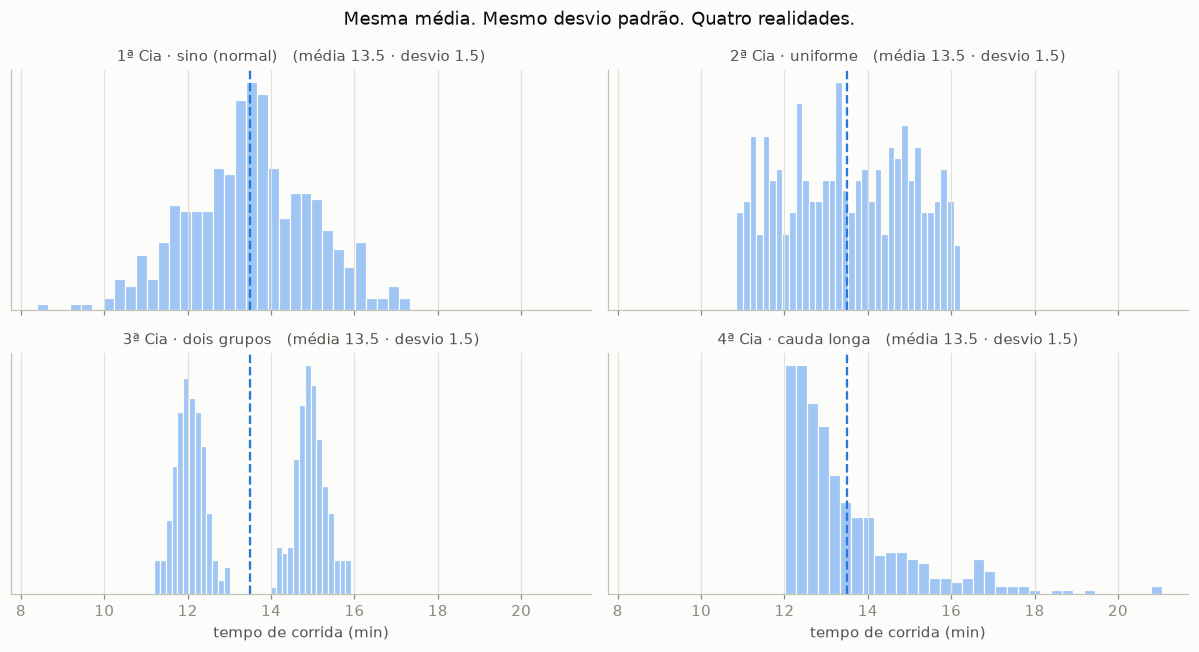

In [3]:
# --- Os mesmos quatro resumos, agora com a forma à mostra ---
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)

for ax, (nome, x) in zip(axes.ravel(), companhias.items()):
    ax.hist(x, bins=34, color=COR["dados"], edgecolor="#fcfcfb", linewidth=0.8)
    ax.axvline(x.mean(), color=COR["media"], linestyle="--", linewidth=1.5)
    ax.set_title(f"{nome}   (média {x.mean():.1f} · desvio {x.std(ddof=1):.1f})",
                 fontsize=10, color="#52514e")
    ax.set_yticks([])

axes[1, 0].set_xlabel("tempo de corrida (min)")
axes[1, 1].set_xlabel("tempo de corrida (min)")
fig.suptitle("Mesma média. Mesmo desvio padrão. Quatro realidades.", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

> ### 🔑 A ideia central do módulo
> Média e desvio padrão são um **resumo com perda**. Eles comprimem centenas de militares em dois
> números — e infinitas realidades diferentes cabem no mesmo par.
>
> A **forma** da distribuição é o que decide:
> - se o resumo que você reportou significa alguma coisa;
> - se a regra "±2 desvios cobre 95%" vale (Módulo 2, §4.2);
> - se aquele valor extremo é um erro ou é a informação mais importante da base.
>
> **Regra de trabalho: olhe o histograma antes de calcular qualquer coisa.**

E repare no que aconteceria com cada companhia numa missão que exige chegada em 14,5 min:

In [4]:
# --- A mesma decisão, quatro respostas ---
print("Militares que estouram o limite de 14,5 min (de 400 em cada companhia):\n")
fora_de_cada = {}
for nome, x in companhias.items():
    fora_de_cada[nome] = np.sum(x > 14.5)
    print(f"  {nome:<24} {fora_de_cada[nome]:>4}  {'█' * int(fora_de_cada[nome] / 4)}")

pior, melhor = max(fora_de_cada.values()), min(fora_de_cada.values())
print(f"\nMesmo resumo estatístico. De {melhor} a {pior} militares fora do critério —")
print(f"uma diferença de {pior - melhor} militares, ou {(pior/melhor - 1)*100:.0f}% a mais.")
print("Quem decidiu com base em 'média 13,5 ± 1,5' decidiu no escuro.")

Militares que estouram o limite de 14,5 min (de 400 em cada companhia):

  1ª Cia · sino (normal)    101  █████████████████████████
  2ª Cia · uniforme         125  ███████████████████████████████
  3ª Cia · dois grupos      179  ████████████████████████████████████████████
  4ª Cia · cauda longa       78  ███████████████████

Mesmo resumo estatístico. De 78 a 179 militares fora do critério —
uma diferença de 101 militares, ou 129% a mais.
Quem decidiu com base em 'média 13,5 ± 1,5' decidiu no escuro.


Dizemos escuro pois, se o S3 perguntar quantos militares estouraram o limite de 14,5, a resposta irá de 78 a 179 (dependendo da cia). Uma cia precisa de um plano de treinamento para 179 e, outra, para 78. Portanto o resumo de média e desvio padrão por cia não é suficiente.

Se esse S3 aplicasse a regra da normal ao resumo que recebeu, ele calcularia que 14,5 min está a 0,67 desvio acima da média, e chegaria a exatamente 101 militares — que é o número da 1ª Cia (a normal), e só dela. Ele erraria por 78 militares na 3ª Cia e por 23 na 4ª, com toda a aparência de estar fazendo a conta certa. É a ligação direta com o Módulo 2, §4.2: a regra 68-95-99,7 não avisa quando quebra.

---
# ① Quantis: descrever sem assumir nada

Toda fórmula do Módulo 2 (média + k desvios, regra 68-95-99,7) assume alguma coisa sobre a forma.
Os **quantis** não assumem nada — eles apenas **leem a fila ordenada**.

- **Percentil 90 = 15,4 min** significa exatamente uma coisa: *90% dos militares chegaram em até
  15,4 min*. Sem hipótese nenhuma sobre distribuição.
- A **mediana** do Módulo 1 é só o percentil 50.
- E, como a mediana, os percentis **atravessam transformações monótonas** (Módulo 1, §1.3), ou seja, aplicar uma funcao aos dados não muda a ordem dos percentis, eles continuaram na mesma ordem.

In [5]:
# --- Lendo a distribuição pelos quantis, sem fórmula nenhuma ---
cia4 = companhias["4ª Cia · cauda longa"]

print("4ª Cia (cauda longa) — leitura direta da fila ordenada:\n")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  percentil {p:>2}: {np.percentile(cia4, p):>6.2f} min"
          f"   ({p}% da tropa chega em até esse tempo)")

print(f"\nMédia:   {cia4.mean():.2f} min")
print(f"Mediana: {np.median(cia4):.2f} min")
print("\nA média está acima da mediana — sintoma clássico de cauda à direita (§3).")
print("Repare que do P50 ao P90 são ~2 min; do P90 ao P99, mais 2,5 min.")
print("A tropa não é simétrica: a metade lenta é MUITO mais espalhada que a rápida.")

4ª Cia (cauda longa) — leitura direta da fila ordenada:

  percentil 10:  12.19 min   (10% da tropa chega em até esse tempo)
  percentil 25:  12.45 min   (25% da tropa chega em até esse tempo)
  percentil 50:  12.97 min   (50% da tropa chega em até esse tempo)
  percentil 75:  14.02 min   (75% da tropa chega em até esse tempo)
  percentil 90:  15.59 min   (90% da tropa chega em até esse tempo)
  percentil 95:  16.73 min   (95% da tropa chega em até esse tempo)
  percentil 99:  18.57 min   (99% da tropa chega em até esse tempo)

Média:   13.50 min
Mediana: 12.97 min

A média está acima da mediana — sintoma clássico de cauda à direita (§3).
Repare que do P50 ao P90 são ~2 min; do P90 ao P99, mais 2,5 min.
A tropa não é simétrica: a metade lenta é MUITO mais espalhada que a rápida.


## 💡 A armadilha: existe mais de uma definição de "percentil"

Com `n` militares você tem `n` valores observados, mas quer cortar a fila em posições que quase
nunca caem exatamente em cima de um deles. O que fazer no meio do caminho? **Interpolar? Arredondar
para baixo? Para cima?**

Cada resposta é uma definição válida. O `numpy` implementa **nove**. O Excel usa outra. É por isso
que dois relatórios sobre os **mesmos dados** apresentam percentis diferentes — e ninguém errou.

Em amostras grandes a diferença é irrelevante. Em pelotões de 12, não é.

In [6]:
# --- O mesmo P90, sete definições diferentes, nos mesmos 12 militares ---
pelotao = np.array([12.8, 13.5, 12.1, 14.0, 13.2, 12.9, 13.7, 12.4, 13.9, 13.1, 12.6, 22.0])

print("Tempos ordenados:", np.sort(pelotao))
print(f"\nPercentil 90 do MESMO pelotão, por método:\n")
for metodo in ["linear", "lower", "higher", "nearest", "midpoint",
               "inverted_cdf", "averaged_inverted_cdf"]:
    valor = np.quantile(pelotao, 0.90, method=metodo)
    print(f"  {metodo:<24}: {valor:>6.3f} min")

print("\nDe 13,9 a 14,0 min — e nenhum desses números está errado.")
print("Moral: em amostra pequena, DIGA qual método você usou, ou reporte o valor")
print("observado mais próximo. Nunca discuta a 3ª casa decimal de um percentil de 12 dados.")

Tempos ordenados: [12.1 12.4 12.6 12.8 12.9 13.1 13.2 13.5 13.7 13.9 14.  22. ]

Percentil 90 do MESMO pelotão, por método:

  linear                  : 13.990 min
  lower                   : 13.900 min
  higher                  : 14.000 min
  nearest                 : 14.000 min
  midpoint                : 13.950 min
  inverted_cdf            : 14.000 min
  averaged_inverted_cdf   : 14.000 min

De 13,9 a 14,0 min — e nenhum desses números está errado.
Moral: em amostra pequena, DIGA qual método você usou, ou reporte o valor
observado mais próximo. Nunca discuta a 3ª casa decimal de um percentil de 12 dados.


---
# ② O boxplot por dentro

O boxplot é a forma mais eficiente de comparar várias distribuições ao mesmo tempo — e a mais
mal interpretada da estatística aplicada. Vamos abrir a caixa.

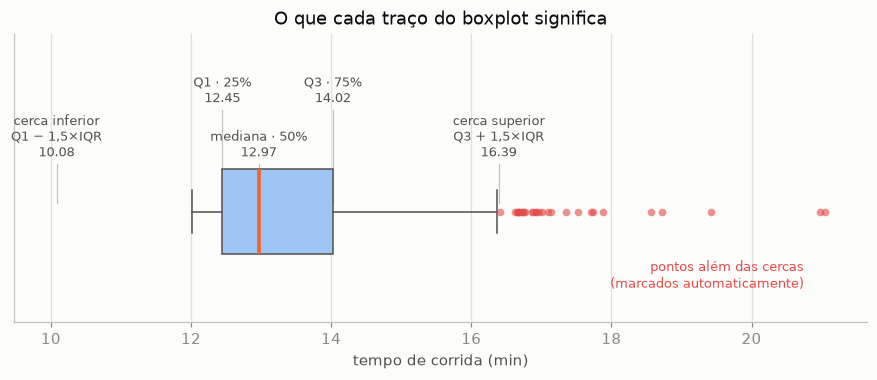

A CAIXA contém os 50% do meio da tropa: de 12.45 a 14.02 min (IQR = 1.58).
Os BIGODES vão até o último dado REAL dentro das cercas — não até as cercas.
Neste caso, 28 militares foram marcados como pontos isolados.


In [7]:
# --- Anatomia do boxplot ---
dados = companhias["4ª Cia · cauda longa"]
q1, q2, q3 = np.percentile(dados, [25, 50, 75])
iqr = q3 - q1
cerca_inf, cerca_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(10, 3.4))
bp = ax.boxplot(dados, orientation="horizontal", widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=COR["dados"], edgecolor="#52514e"),
                medianprops=dict(color=COR["mediana"], linewidth=2.5),
                whiskerprops=dict(color="#52514e"), capprops=dict(color="#52514e"),
                flierprops=dict(marker="o", markerfacecolor=COR["alerta"],
                                markeredgecolor="none", markersize=5, alpha=0.6))

marcas = [(cerca_inf, "cerca inferior\nQ1 − 1,5×IQR", 1.30),
          (q1, "Q1 · 25%", 1.62), (q2, "mediana · 50%", 1.30), (q3, "Q3 · 75%", 1.62),
          (cerca_sup, "cerca superior\nQ3 + 1,5×IQR", 1.30)]
for valor, rotulo, altura in marcas:
    ax.annotate(f"{rotulo}\n{valor:.2f}", xy=(valor, altura), ha="center", va="bottom",
                fontsize=8.5, color="#52514e")
    ax.plot([valor, valor], [1.05, altura - 0.02], color="#c3c2b7", linewidth=0.8, zorder=0)

ax.annotate("pontos além das cercas\n(marcados automaticamente)", xy=(dados.max() - 0.3, 0.55),
            ha="right", fontsize=8.5, color=COR["alerta"])
ax.set_xlim(cerca_inf - 0.6, dados.max() + 0.6)
ax.set_ylim(0.35, 2.05)
ax.set_yticks([])
ax.set_xlabel("tempo de corrida (min)")
ax.set_title("O que cada traço do boxplot significa", color="#0b0b0b")
plt.show()

print(f"A CAIXA contém os 50% do meio da tropa: de {q1:.2f} a {q3:.2f} min (IQR = {iqr:.2f}).")
print("Os BIGODES vão até o último dado REAL dentro das cercas — não até as cercas.")
print(f"Neste caso, {np.sum(dados > cerca_sup)} militares foram marcados como pontos isolados.")

## 2.1 · De onde vem o 1,5?

A pergunta que nunca é respondida em aula. O `1,5` não é sagrado nem foi deduzido: foi uma
**escolha de projeto** de John Tukey, nos anos 1970, calibrada assim:

Em uma distribuição **normal**, o IQR (amplitude interquartil) vale cerca de `1,35 σ`. Logo:

```
cerca = Q3 + 1,5 × IQR  ≈  0,67σ + 1,5 × 1,35σ  ≈  2,7 σ
```

Ou seja: a regra do 1,5 é, na prática, **"marque o que passar de ±2,7 desvios padrão"** — o que
em dados normais corresponde a cerca de **0,7% dos pontos**. Tukey queria um filtro que raramente
disparasse por acaso, mas que não deixasse passar nada relevante. `1,5` foi o número que deu essa
conta redonda.

**Consequência que quase ninguém tira:** se 0,7% dos pontos são marcados **por acaso**, então numa
amostra grande e perfeitamente limpa o boxplot **sempre** vai marcar gente.

In [8]:
# --- Quantos "outliers" o boxplot marca em dados SEM NENHUM erro? ---
rng = np.random.default_rng(21)

print("Dados 100% normais, sem contaminação nenhuma:\n")
print(f"{'tamanho da amostra':>20} | {'marcados':>9} | {'% marcado':>10}")
print("-" * 46)
for n in [12, 50, 200, 1000, 10_000]:
    marcados = []
    for _ in range(400):
        x = rng.normal(13.5, 1.5, n)
        q1_, q3_ = np.percentile(x, [25, 75])
        cercas = 1.5 * (q3_ - q1_)
        marcados.append(np.sum((x < q1_ - cercas) | (x > q3_ + cercas)))
    m = np.mean(marcados)
    print(f"{n:>20} | {m:>9.1f} | {m / n * 100:>9.2f}%")

print("\nA taxa converge para ~0,7%, exatamente como previsto pela conta dos 2,7σ.")
print("(Em amostra pequena ela é ainda MAIOR — ~3% com n=12 — porque com poucos dados")
print(" o próprio IQR é instável e a cerca fica apertada por acaso.)")
print("\n>>> Numa base de 10.000 registros LIMPOS, o boxplot marca ~70 pontos. <<<")
print(">>> Ser marcado no boxplot NÃO é evidência de erro.  É só uma sinalização. <<<")

Dados 100% normais, sem contaminação nenhuma:

  tamanho da amostra |  marcados |  % marcado
----------------------------------------------
                  12 |       0.4 |      3.23%
                  50 |       0.7 |      1.41%


                 200 |       1.6 |      0.80%
                1000 |       7.4 |      0.74%


               10000 |      69.9 |      0.70%

A taxa converge para ~0,7%, exatamente como previsto pela conta dos 2,7σ.
(Em amostra pequena ela é ainda MAIOR — ~3% com n=12 — porque com poucos dados
 o próprio IQR é instável e a cerca fica apertada por acaso.)

>>> Numa base de 10.000 registros LIMPOS, o boxplot marca ~70 pontos. <<<
>>> Ser marcado no boxplot NÃO é evidência de erro.  É só uma sinalização. <<<


## 2.2 · O que o boxplot **esconde**

O boxplot é construído sobre 5 números. Tudo que acontece **dentro** da caixa é invisível para
ele — inclusive a coisa mais importante que pode acontecer com os seus dados: haver **dois grupos**.

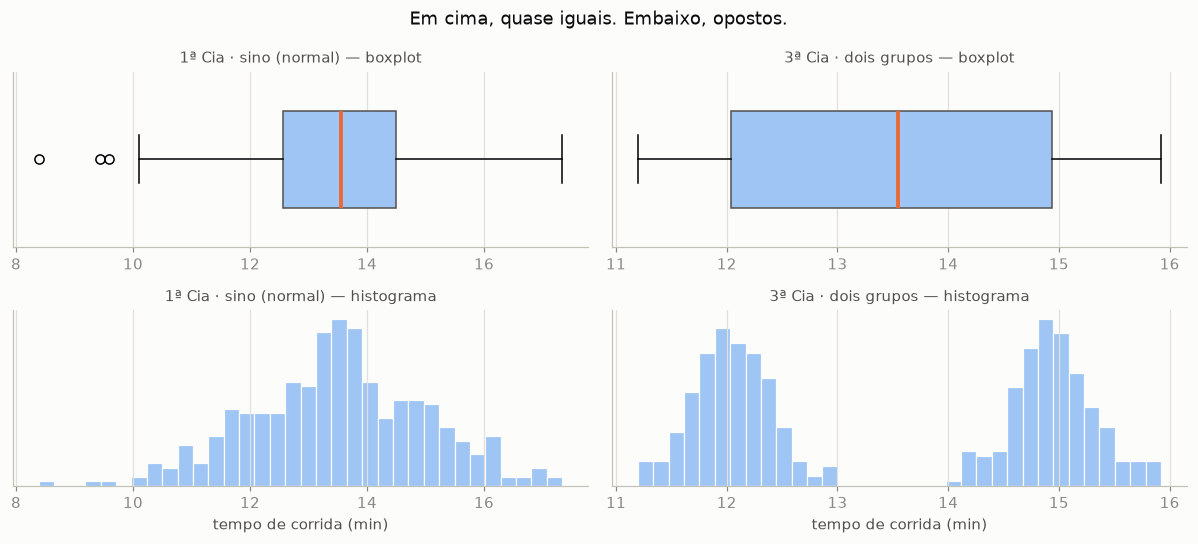

Boxplot é excelente para COMPARAR muitos grupos e localizar assimetria e extremos.
Ele é cego para bimodalidade, para buracos e para dados empilhados em poucos valores.
Use boxplot para comparar; use histograma para entender.


In [9]:
# --- Dois conjuntos, boxplots quase idênticos, realidades opostas ---
um_grupo   = companhias["1ª Cia · sino (normal)"]
dois_grupos = companhias["3ª Cia · dois grupos"]

fig, axes = plt.subplots(2, 2, figsize=(11, 5))

for coluna, (nome, x) in enumerate([("1ª Cia · sino (normal)", um_grupo),
                                    ("3ª Cia · dois grupos", dois_grupos)]):
    axes[0, coluna].boxplot(x, orientation="horizontal", widths=0.55, patch_artist=True,
                            boxprops=dict(facecolor=COR["dados"], edgecolor="#52514e"),
                            medianprops=dict(color=COR["mediana"], linewidth=2.5))
    axes[0, coluna].set_title(f"{nome} — boxplot", fontsize=10, color="#52514e")
    axes[0, coluna].set_yticks([])

    axes[1, coluna].hist(x, bins=34, color=COR["dados"], edgecolor="#fcfcfb", linewidth=0.8)
    axes[1, coluna].set_title(f"{nome} — histograma", fontsize=10, color="#52514e")
    axes[1, coluna].set_yticks([])
    axes[1, coluna].set_xlabel("tempo de corrida (min)")

fig.suptitle("Em cima, quase iguais. Embaixo, opostos.", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

print("Boxplot é excelente para COMPARAR muitos grupos e localizar assimetria e extremos.")
print("Ele é cego para bimodalidade, para buracos e para dados empilhados em poucos valores.")
print("Use boxplot para comparar; use histograma para entender.")

---
# ③ Assimetria: por que média ≠ mediana

No Módulo 1 usamos "média > mediana" como sintoma de outlier. É mais geral do que isso: é o
sintoma de **assimetria** — a cauda de um lado sendo mais longa que a do outro.

| Situação | Relação | Exemplo típico |
|---|---|---|
| **Simétrica** | média ≈ mediana | altura, peso, erro de medida |
| **Cauda à direita** (positiva) | **média > mediana** | tempo, renda, prejuízo, tempo de espera |
| **Cauda à esquerda** (negativa) | **média < mediana** | notas com teto, idade de aposentadoria |

E há uma razão estrutural para a cauda à direita ser tão comum em dados operacionais: **existe um
piso e não existe teto.** Ninguém corre 3 km em −2 minutos, mas alguém pode levar 40 se torcer o
tornozelo. O fenômeno é assimétrico por natureza — não é defeito da coleta.

In [10]:
# --- Medindo a assimetria das quatro companhias ---
print(f"{'companhia':<22} | {'média':>7} | {'mediana':>8} | {'méd-med':>8} | {'assimetria':>11}")
print("-" * 70)
for nome, x in companhias.items():
    print(f"{nome:<22} | {x.mean():>7.2f} | {np.median(x):>8.2f} | "
          f"{x.mean() - np.median(x):>+8.2f} | {stats.skew(x):>11.2f}")

print("\nO coeficiente de assimetria (skewness) resume o mesmo sinal num número:")
print("  ≈ 0  -> simétrica    |    > 0 -> cauda à direita    |    < 0 -> cauda à esquerda")
print("\nRegra de bolso: |assimetria| acima de ~1 já é forte o bastante para você")
print("desconfiar da média e de qualquer fórmula que suponha normalidade.")

companhia              |   média |  mediana |  méd-med |  assimetria
----------------------------------------------------------------------
1ª Cia · sino (normal) |   13.50 |    13.55 |    -0.05 |       -0.08
2ª Cia · uniforme      |   13.50 |    13.43 |    +0.07 |       -0.01
3ª Cia · dois grupos   |   13.50 |    13.54 |    -0.04 |        0.01
4ª Cia · cauda longa   |   13.50 |    12.97 |    +0.53 |        1.79

O coeficiente de assimetria (skewness) resume o mesmo sinal num número:
  ≈ 0  -> simétrica    |    > 0 -> cauda à direita    |    < 0 -> cauda à esquerda

Regra de bolso: |assimetria| acima de ~1 já é forte o bastante para você
desconfiar da média e de qualquer fórmula que suponha normalidade.


### E a curtose? (o termo mais mal explicado da estatística)

Você vai ouvir que curtose mede "achatamento". **Não mede.** Curtose mede o **peso das caudas** —
a propensão da distribuição a produzir valores muito distantes do centro.

Isso importa para uma decisão prática: se as caudas são pesadas, eventos extremos são **muito**
mais frequentes do que a normal prevê, e todo dimensionamento baseado em `média + k·σ` fica curto.

In [11]:
# --- Três distribuições com a MESMA média e o MESMO desvio, caudas diferentes ---
rng = np.random.default_rng(13)
n = 200_000

caudas = {
    "uniforme (cauda leve)": padronizar(rng.uniform(-1, 1, n)),
    "normal (referência)":   padronizar(rng.normal(0, 1, n)),
    "t de Student (pesada)": padronizar(rng.standard_t(6, n)),
}

resumo = {}
print(f"{'distribuição':<24} | {'curtose':>8} | {'além de 3σ':>11} | {'pior caso':>10}")
print("-" * 62)
for nome, x in caudas.items():
    m, s = x.mean(), x.std(ddof=1)
    resumo[nome] = (np.mean(np.abs(x - m) > 3 * s) * 100, x.max())
    print(f"{nome:<24} | {stats.kurtosis(x):>8.2f} | {resumo[nome][0]:>10.2f}% | {resumo[nome][1]:>10.2f}")

print(f"\nAs três têm média {ALVO_MEDIA} e desvio {ALVO_DESVIO}. E são profundamente diferentes:")
print("Curtose 0 = mesma cauda da normal | > 0 = cauda pesada | < 0 = cauda leve.")
print()
print(f"Além de 3σ: a uniforme NUNCA passa ({resumo['uniforme (cauda leve)'][0]:.2f}%);")
print(f"            a normal, {resumo['normal (referência)'][0]:.2f}%; a t de Student, {resumo['t de Student (pesada)'][0]:.2f}% "
      f"— {resumo['t de Student (pesada)'][0] / resumo['normal (referência)'][0]:.0f}x mais que a normal.")
print(f"Pior caso : a uniforme para em {resumo['uniforme (cauda leve)'][1]:.1f} min; "
      f"a t de Student chega a {resumo['t de Student (pesada)'][1]:.1f} min.")
print("\nSe o seu plano de contingência foi calibrado por σ, a cauda pesada te pega.")

distribuição             |  curtose |  além de 3σ |  pior caso
--------------------------------------------------------------
uniforme (cauda leve)    |    -1.20 |       0.00% |      16.10
normal (referência)      |     0.01 |       0.28% |      20.15
t de Student (pesada)    |     2.43 |       1.04% |      28.72

As três têm média 13.5 e desvio 1.5. E são profundamente diferentes:
Curtose 0 = mesma cauda da normal | > 0 = cauda pesada | < 0 = cauda leve.

Além de 3σ: a uniforme NUNCA passa (0.00%);
            a normal, 0.28%; a t de Student, 1.04% — 4x mais que a normal.
Pior caso : a uniforme para em 16.1 min; a t de Student chega a 28.7 min.

Se o seu plano de contingência foi calibrado por σ, a cauda pesada te pega.


---
# ④ Outlier é uma hipótese, não um veredito

Este é o ponto do módulo com maior chance de evitar um erro caro na vida real.

Nenhuma fórmula sabe se um ponto extremo é lixo ou informação. Ela só sabe que ele está longe.
**Quem decide é você, investigando a origem do dado.** E existem três origens possíveis, com
três condutas opostas:

| Causa | Como identificar | Conduta |
|---|---|---|
| **1. Erro de registro** | valor impossível (1,90 s nos 3 km), unidade trocada, dígito a mais | corrigir ou remover — **e documentar** |
| **2. Variação legítima extrema** | valor raro mas fisicamente possível (o militar lesionado) | **MANTER.** Costuma ser o dado mais informativo da base |
| **3. Outra população misturada** | os extremos formam um grupo coerente, não pontos soltos | **separar** e analisar em separado |

> ### 🔑 Nunca remova outliers por regra automática
> Um filtro automático não distingue as três causas. Ele remove as três — inclusive a segunda,
> que costuma ser exatamente o que a análise deveria ter encontrado.

E há uma consequência técnica desagradável de aplicar filtros sem pensar:

In [12]:
# --- O que acontece quando você remove "outliers" repetidamente ---
rng = np.random.default_rng(4)
base = rng.exponential(3.0, 500) + 11.0   # tempos com cauda longa, TODOS legítimos

x = base.copy()
print(f"{'passada':>8} | {'sobraram':>9} | {'removidos':>10} | {'máximo':>8} | {'desvio':>7}")
print("-" * 54)
print(f"{'inicial':>8} | {len(x):>9} | {'-':>10} | {x.max():>8.2f} | {x.std(ddof=1):>7.2f}")

for passada in range(1, 8):
    q1_, q3_ = np.percentile(x, [25, 75])
    limite = q3_ + 1.5 * (q3_ - q1_)
    novo = x[x <= limite]
    if len(novo) == len(x):
        print(f"{passada:>8} | {'estabilizou':>9}")
        break
    print(f"{passada:>8} | {len(novo):>9} | {len(x) - len(novo):>10} | {novo.max():>8.2f} | {novo.std(ddof=1):>7.2f}")
    x = novo

print(f"\nDe {len(base)} militares sobraram {len(x)} — e NENHUM dos removidos era erro.")
print("Cada remoção encolhe o IQR, que baixa a cerca, que cria novos 'outliers'.")
print("O filtro se alimenta do próprio resultado até a distribuição virar outra coisa.")
print("\nO que você acabou de fazer não foi limpar dados. Foi fabricar uma tropa que não existe.")

 passada |  sobraram |  removidos |   máximo |  desvio
------------------------------------------------------
 inicial |       500 |          - |    30.56 |    3.17
       1 |       462 |         38 |    19.56 |    2.00
       2 |       449 |         13 |    18.32 |    1.78
       3 |       447 |          2 |    18.14 |    1.75
       4 |       445 |          2 |    18.01 |    1.73
       5 |       443 |          2 |    17.93 |    1.70
       6 |       441 |          2 |    17.70 |    1.67
       7 | estabilizou

De 500 militares sobraram 441 — e NENHUM dos removidos era erro.
Cada remoção encolhe o IQR, que baixa a cerca, que cria novos 'outliers'.
O filtro se alimenta do próprio resultado até a distribuição virar outra coisa.

O que você acabou de fazer não foi limpar dados. Foi fabricar uma tropa que não existe.


## 4.1 · Por que a regra dos 3σ falha justamente quando você precisa

A detecção de outlier mais usada no mundo corporativo é `|x − média| > 3 × desvio padrão`.
Ela tem um defeito fatal, que é consequência direta do Módulo 2: **o outlier entra no cálculo da
média e do desvio padrão que deveriam denunciá-lo**. Ele infla o próprio σ que serviria para
acusá-lo. O fenômeno tem nome: **mascaramento** (*masking*).

E o mascaramento não é só uma tendência — em amostra pequena ele é uma **impossibilidade
matemática**. Existe um teto para o escore z que qualquer ponto pode atingir:

> **|z| máximo possível = (n − 1) / √n**

Com `n = 10`, esse teto é **2,85**. Ou seja: num conjunto de 10 registros, **nenhum valor, por mais
absurdo que seja, pode ultrapassar 3 desvios padrão**. A regra dos 3σ é literalmente incapaz de
disparar. Vamos ver isso acontecer.

In [13]:
# --- Mascaramento: o outlier escondendo a si mesmo ---
limpo = np.array([12.8, 13.5, 12.1, 14.0, 13.2, 12.9, 13.7, 12.4, 13.9])   # 9 militares normais

print("9 militares normais + 1 registro absurdo. Vamos aumentar o absurdo:\n")
print(f"{'valor registrado':>17} | {'média':>8} | {'desvio':>9} | {'escore z':>9} | {'3σ acusa?':>10}")
print("-" * 66)
for valor in [25.0, 95.0, 1_000.0, 1_000_000.0]:
    x = np.append(limpo, valor)
    z = (valor - x.mean()) / x.std(ddof=1)
    print(f"{valor:>17,.0f} | {x.mean():>8.1f} | {x.std(ddof=1):>9.1f} | {z:>9.3f} | "
          f"{'SIM' if z > 3 else 'não ❌':>10}")

n = len(limpo) + 1
print(f"\nO escore z converge para o teto e trava: (n-1)/√n = {(n-1)/np.sqrt(n):.3f} < 3.")
print("Um registro de 1 MILHÃO de minutos não é detectado pela regra dos 3σ.")
print("Não é azar dos dados: é aritmética. Ele arrasta a média e infla o σ junto com ele.")

9 militares normais + 1 registro absurdo. Vamos aumentar o absurdo:

 valor registrado |    média |    desvio |  escore z |  3σ acusa?
------------------------------------------------------------------
               25 |     14.3 |       3.8 |     2.807 |      não ❌
               95 |     21.4 |      25.9 |     2.845 |      não ❌
            1,000 |    111.8 |     312.1 |     2.846 |      não ❌
        1,000,000 | 100011.9 |  316223.6 |     2.846 |      não ❌

O escore z converge para o teto e trava: (n-1)/√n = 2.846 < 3.
Um registro de 1 MILHÃO de minutos não é detectado pela regra dos 3σ.
Não é azar dos dados: é aritmética. Ele arrasta a média e infla o σ junto com ele.


In [14]:
# --- A correção: mediana e MAD, que o outlier não consegue contaminar ---
com_erro = np.append(limpo, 95.0)

def detectar_3sigma(x):
    return np.abs(x - x.mean()) > 3 * x.std(ddof=1)

def detectar_mad(x):
    mad = np.median(np.abs(x - np.median(x)))
    escore = 0.6745 * (x - np.median(x)) / mad     # "escore z modificado"
    return np.abs(escore) > 3.5

print(f"{'':<28} | {'centro':>8} | {'escala':>8}")
print("-" * 50)
print(f"{'clássico (sem o erro)':<28} | {limpo.mean():>8.2f} | {limpo.std(ddof=1):>8.2f}")
print(f"{'clássico (com o erro)':<28} | {com_erro.mean():>8.2f} | {com_erro.std(ddof=1):>8.2f}  <- destruído")
print(f"{'robusto  (sem o erro)':<28} | {np.median(limpo):>8.2f} | {np.median(np.abs(limpo-np.median(limpo))):>8.2f}")
print(f"{'robusto  (com o erro)':<28} | {np.median(com_erro):>8.2f} | {np.median(np.abs(com_erro-np.median(com_erro))):>8.2f}  <- intacto ✅")

print(f"\nregra dos 3σ detectou: {com_erro[detectar_3sigma(com_erro)]}   ❌ (nada)")
print(f"regra do MAD detectou: {com_erro[detectar_mad(com_erro)]}   ✅")
print("\nUse escore z modificado (mediana + MAD) para TRIAGEM de erros de registro.")
print("A regra dos 3σ só é confiável em amostra grande e sem contaminação — ou seja,")
print("exatamente na situação em que você não precisa dela.")

                             |   centro |   escala
--------------------------------------------------
clássico (sem o erro)        |    13.17 |     0.67
clássico (com o erro)        |    21.35 |    25.89  <- destruído
robusto  (sem o erro)        |    13.20 |     0.50
robusto  (com o erro)        |    13.35 |     0.55  <- intacto ✅

regra dos 3σ detectou: []   ❌ (nada)
regra do MAD detectou: [95.]   ✅

Use escore z modificado (mediana + MAD) para TRIAGEM de erros de registro.
A regra dos 3σ só é confiável em amostra grande e sem contaminação — ou seja,
exatamente na situação em que você não precisa dela.


---
# ⑤ Transformar não é trapacear

Quando os dados são fortemente assimétricos, existe uma alternativa a abandonar as ferramentas
clássicas: **mudar a escala em que você olha**.

A justificativa é a mesma do Módulo 1, §3.3: você não transforma para "consertar" os dados, você
transforma para chegar à escala **em que o fenômeno é aditivo**. Se o efeito é multiplicativo
(cada fator de fadiga multiplica o tempo, em vez de somar minutos), a escala natural é o **log**.

E o Módulo 1 já nos deu a garantia de que isso não corrompe a interpretação: a **mediana atravessa**
a transformação intacta (`mediana(log x) = log(mediana x)`).

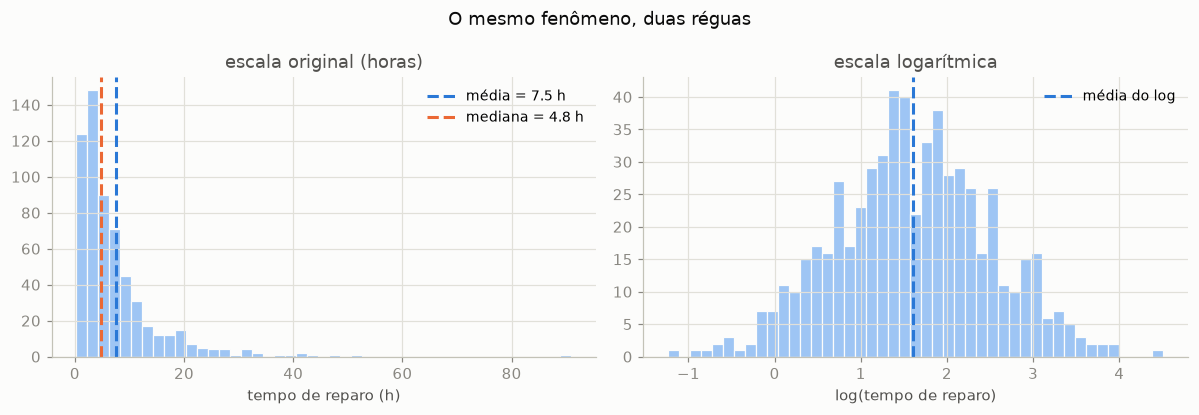

assimetria na escala original:   3.63
assimetria na escala log .....:  -0.01   <- praticamente simétrica

média aritmética ..............:   7.46 h
mediana .......................:   4.80 h
exp(média dos logs) = geométrica:   4.97 h

A média geométrica cai quase em cima da mediana — porque na escala log
a distribuição é simétrica, e lá média e mediana coincidem (Módulo 1, §1.3).


In [15]:
# --- Tempos de reparo de viatura: assimetria clássica ---
rng = np.random.default_rng(8)
reparos = rng.lognormal(mean=1.6, sigma=0.9, size=600)   # horas

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(reparos, bins=45, color=COR["dados"], edgecolor="#fcfcfb", linewidth=0.8)
axes[0].axvline(reparos.mean(),   color=COR["media"],   linestyle="--", label=f"média = {reparos.mean():.1f} h")
axes[0].axvline(np.median(reparos), color=COR["mediana"], linestyle="--", label=f"mediana = {np.median(reparos):.1f} h")
axes[0].set_title("escala original (horas)", color="#52514e")
axes[0].set_xlabel("tempo de reparo (h)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].hist(np.log(reparos), bins=45, color=COR["dados"], edgecolor="#fcfcfb", linewidth=0.8)
axes[1].axvline(np.log(reparos).mean(), color=COR["media"], linestyle="--", label="média do log")
axes[1].set_title("escala logarítmica", color="#52514e")
axes[1].set_xlabel("log(tempo de reparo)")
axes[1].legend(frameon=False, fontsize=9)

fig.suptitle("O mesmo fenômeno, duas réguas", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

print(f"assimetria na escala original: {stats.skew(reparos):>6.2f}")
print(f"assimetria na escala log .....: {stats.skew(np.log(reparos)):>6.2f}   <- praticamente simétrica")
print()
print(f"média aritmética ..............: {reparos.mean():>6.2f} h")
print(f"mediana .......................: {np.median(reparos):>6.2f} h")
print(f"exp(média dos logs) = geométrica: {np.exp(np.mean(np.log(reparos))):>6.2f} h")
print("\nA média geométrica cai quase em cima da mediana — porque na escala log")
print("a distribuição é simétrica, e lá média e mediana coincidem (Módulo 1, §1.3).")

---
# ⑥ Por que a normal aparece tanto — e quando ela não aparece

A distribuição normal não é uma lei da natureza nem uma suposição de conveniência. Ela é o que
**acontece** quando um resultado é a **soma de muitos efeitos pequenos e independentes**.

Vamos ver isso nascer. O experimento: somar `k` fatores completamente **uniformes** — cada um
sorteado com a mesma chance em toda a faixa, sem nada de "sino". Aumentamos `k` e olhamos a forma
do total.

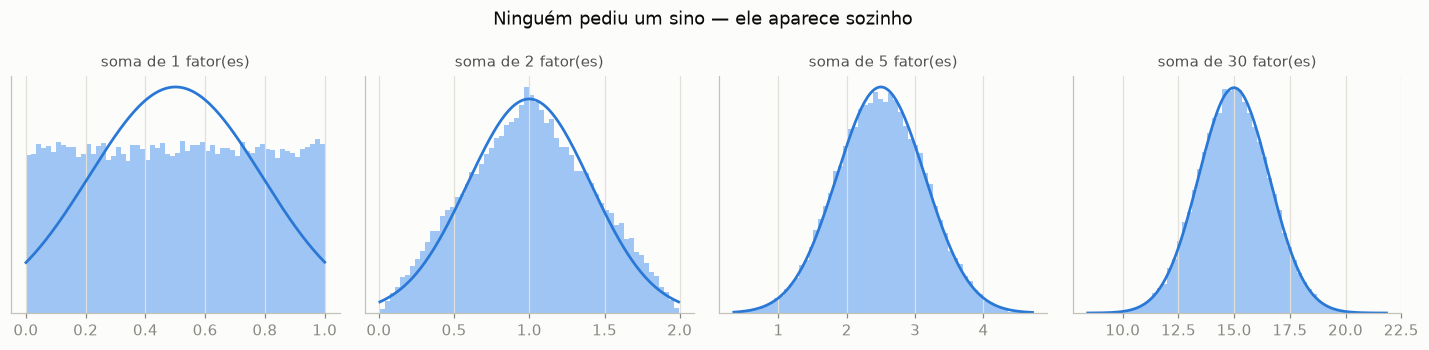

Com 1 fator: retângulo perfeito, nada de sino.
Com 2: já vira um triângulo. Com 5: praticamente indistinguível da normal.

É o Teorema Central do Limite, e ele explica por que a normal aparece em
altura, erro de medida, peso e notas: são resultados de MUITAS causinhas somadas.


In [16]:
# --- A normal nascendo da soma de fatores que não têm nada de normal ---
rng = np.random.default_rng(15)
N = 60_000

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, k in zip(axes, [1, 2, 5, 30]):
    soma = rng.uniform(0, 1, size=(N, k)).sum(axis=1)
    ax.hist(soma, bins=60, color=COR["dados"], edgecolor="none", density=True)
    # curva normal com a mesma média e o mesmo desvio, para comparação
    grade = np.linspace(soma.min(), soma.max(), 200)
    ax.plot(grade, stats.norm.pdf(grade, soma.mean(), soma.std()), color=COR["media"], linewidth=1.8)
    ax.set_title(f"soma de {k} fator(es)", fontsize=10, color="#52514e")
    ax.set_yticks([])

fig.suptitle("Ninguém pediu um sino — ele aparece sozinho", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

print("Com 1 fator: retângulo perfeito, nada de sino.")
print("Com 2: já vira um triângulo. Com 5: praticamente indistinguível da normal.")
print("\nÉ o Teorema Central do Limite, e ele explica por que a normal aparece em")
print("altura, erro de medida, peso e notas: são resultados de MUITAS causinhas somadas.")

### E quando o fenômeno **não** é uma soma?

| O resultado é... | A forma que aparece | Exemplos |
|---|---|---|
| **soma** de muitos efeitos | **normal** | altura, erro de medição, média amostral |
| **produto** de muitos efeitos | **lognormal** (cauda à direita) | tempo de reparo, renda, crescimento |
| **contagem de eventos raros** | **Poisson** | acidentes por mês, falhas por 1.000 h |
| **tempo até um evento** | **exponencial / Weibull** | vida útil de peça, tempo entre chamados |
| **o máximo** de muitos valores | **valor extremo** | cheia máxima anual, pico de demanda |

Repare que quase tudo que é **tempo** ou **dinheiro** cai fora da normal. Não é exceção: é a regra
em dados operacionais.

## 6.1 · Como verificar: use os olhos, não o teste

Existem testes formais de normalidade (Shapiro-Wilk, Kolmogorov-Smirnov). Eles têm um problema
prático sério: em amostras grandes, eles **rejeitam tudo** — porque nenhum dado real é
exatamente normal, e com muitos dados até um desvio irrelevante vira "significativo".

O **QQ-plot** é mais honesto: ele compara os seus quantis com os quantis da normal. Se os pontos
seguem a reta, a aproximação serve. Se fogem nas pontas, você vê **onde** e **quanto**.

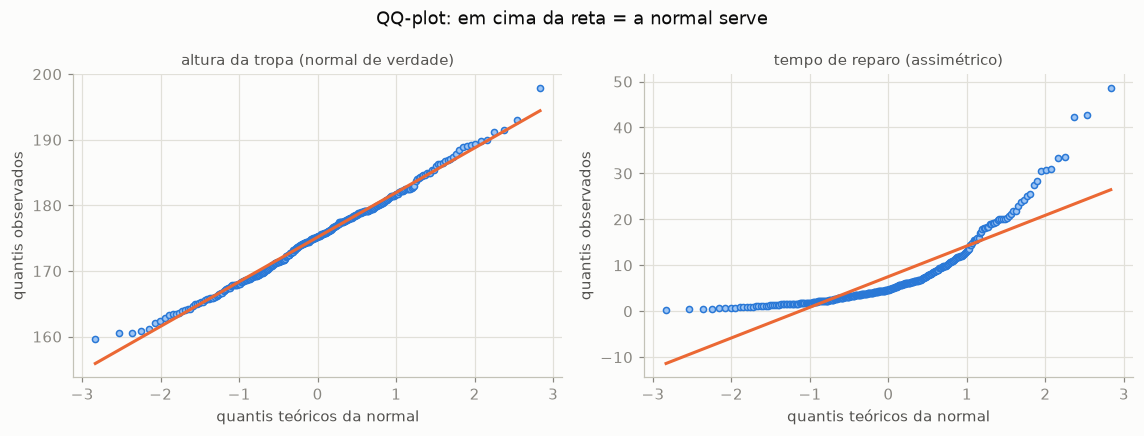

Shapiro-Wilk · altura ..........: p = 2.93e-01
Shapiro-Wilk · tempo de reparo ..: p = 1.35e-20

À esquerda os pontos seguem a reta; à direita eles descolam violentamente
na ponta de cima — e o QQ-plot mostra EXATAMENTE onde o modelo falha.

Na prática: olhe o QQ-plot primeiro; use o teste como confirmação, nunca como juiz.


In [17]:
# --- QQ-plot: dados normais × dados assimétricos ---
altura = rng.normal(175, 7, 300)      # gerados de uma normal DE VERDADE
reparo_300 = reparos[:300]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

for ax, (titulo, x) in zip(axes, [("altura da tropa (normal de verdade)", altura),
                                  ("tempo de reparo (assimétrico)", reparo_300)]):
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=4, color=COR["dados"], markeredgecolor=COR["media"])
    ax.get_lines()[1].set(color=COR["mediana"], linewidth=2)
    ax.set_title(titulo, fontsize=10, color="#52514e")
    ax.set_xlabel("quantis teóricos da normal")
    ax.set_ylabel("quantis observados")

fig.suptitle("QQ-plot: em cima da reta = a normal serve", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

p_altura = stats.shapiro(altura).pvalue
p_reparo = stats.shapiro(reparo_300).pvalue
print(f"Shapiro-Wilk · altura ..........: p = {p_altura:.2e}")
print(f"Shapiro-Wilk · tempo de reparo ..: p = {p_reparo:.2e}")

print("\nÀ esquerda os pontos seguem a reta; à direita eles descolam violentamente")
print("na ponta de cima — e o QQ-plot mostra EXATAMENTE onde o modelo falha.")

if p_altura < 0.05:
    print(f"\n>>> E olhe o que o teste fez: rejeitou a normalidade (p = {p_altura:.3f} < 0,05)")
    print(">>> de dados que ELE MESMO gerou de uma normal perfeita. É o falso positivo")
    print(">>> de 5% acontecendo na sua frente. Um veredito binário não sabe dizer isso.")

print("\nNa prática: olhe o QQ-plot primeiro; use o teste como confirmação, nunca como juiz.")

---
# ⑦ Decisão: o que reportar, conforme a forma

| Se a distribuição é... | Reporte | Evite |
|---|---|---|
| **simétrica, sem extremos** | média ± desvio padrão | — |
| **assimétrica** | mediana + quartis (ou P10/P50/P90) | média ± σ e a regra 68-95-99,7 |
| **com extremos legítimos** | mediana + IQR, **e cite os extremos** | remover os extremos |
| **com dois grupos** | os grupos **separados** | qualquer número único |
| **de cauda pesada** | percentis altos (P95, P99) e o máximo | dimensionar por média + k·σ |

### Três frases para levar

1. **Média e desvio padrão são um resumo com perda.** Quatro realidades opostas cabem no mesmo par.
2. **Ser marcado no boxplot não é ser erro.** Em 10.000 registros limpos, ~70 pontos são marcados
   por acaso.
3. **Outlier é uma hipótese a investigar.** Filtro automático não distingue erro de informação —
   e, aplicado em série, come a distribuição inteira.

---
# 🔻 Fechamento do Dia 1 · Por que isso importa para a IA

Você passou o dia aprendendo a descrever **uma** variável: onde ela está (M1), quanto ela se
espalha (M2) e que forma ela tem (M3). Isso não é preparação distante para a inteligência
artificial — é a descrição dos **dados** com que qualquer modelo de IA é treinado.

- **O modelo herda a distribuição que você deu a ele.** Se a base é assimétrica, tem cauda longa
  ou mistura dois grupos, o modelo aprende isso junto. E o "desempenho médio" que ele reporta vai
  esconder exatamente para quem ele falha.
- **Outlier é hipótese, não veredito** — e vale mais ainda aqui. O filtro automático que "limpa"
  a base antes do treino costuma jogar fora justamente o caso raro que importa: a falha, a
  fraude, a ameaça. Em IA, o evento de interesse quase sempre mora na cauda.
- **Normalizar e aplicar log** são os dois primeiros passos de quase todo tutorial de IA. Você
  acabou de ver por quê: é o Módulo 3, §⑤, com outro nome. Fenômenos que **multiplicam** (tempo,
  dinheiro, contagem) precisam de escala log para que as fórmulas façam sentido.
- **Planejar pela média é planejar para ninguém.** O piloto médio de Daniels (M1, §4.1) volta no
  último módulo do curso como o argumento central da **avaliação desagregada**: um modelo julgado
  por um número único é uma cabine projetada para um piloto que não existe.

> **A frase para levar do dia:** antes de perguntar se o modelo é bom, pergunte que **forma**
> tinham os dados que o treinaram — porque é a forma que decide se o resumo que você recebeu
> significa alguma coisa.

---
# ⑧ Exercícios

**Exercício 1 — Preveja antes de rodar.**

Volte às quatro companhias da seção ⓪. Sem executar nada, responda:

1. Em qual delas a **média** e a **mediana** ficam mais distantes uma da outra?
2. Em qual delas o **boxplot** vai marcar mais pontos como outliers?
3. Em qual delas a regra **"±2 desvios cobre 95%"** vai errar mais feio?

In [18]:
# EXERCÍCIO 1 — rode e compare com a sua previsão
print(f"{'companhia':<22} | {'|méd-mediana|':>13} | {'marcados':>9} | {'dentro de ±2σ':>14}")
print("-" * 70)
for nome, x in companhias.items():
    q1_, q3_ = np.percentile(x, [25, 75])
    cerca = 1.5 * (q3_ - q1_)
    marcados = np.sum((x < q1_ - cerca) | (x > q3_ + cerca))
    dentro = np.mean(np.abs(x - x.mean()) <= 2 * x.std(ddof=1)) * 100
    print(f"{nome:<22} | {abs(x.mean() - np.median(x)):>13.2f} | {marcados:>9} | {dentro:>13.1f}%")

print("\n(a regra 68-95-99,7 promete 95,4% na última coluna)")
print("\nRepare que os erros têm SINAIS diferentes, e isso muda tudo na prática:")
print("  cobrir MAIS que o prometido é conservador — você planeja folga a mais;")
print("  cobrir MENOS é perigoso — mais gente fora do previsto do que você contou ao comando.")

companhia              | |méd-mediana| |  marcados |  dentro de ±2σ
----------------------------------------------------------------------
1ª Cia · sino (normal) |          0.05 |         3 |          95.5%
2ª Cia · uniforme      |          0.07 |         0 |         100.0%
3ª Cia · dois grupos   |          0.04 |         0 |         100.0%
4ª Cia · cauda longa   |          0.53 |        28 |          93.2%

(a regra 68-95-99,7 promete 95,4% na última coluna)

Repare que os erros têm SINAIS diferentes, e isso muda tudo na prática:
  cobrir MAIS que o prometido é conservador — você planeja folga a mais;
  cobrir MENOS é perigoso — mais gente fora do previsto do que você contou ao comando.


**Exercício 2 — Mude um parâmetro.**

Na célula abaixo, mude `MULTIPLICADOR` (a regra padrão do boxplot usa 1,5; teste 1,0 · 2,0 · 3,0).

1. Quantos militares são marcados com cada valor?
2. Existe um valor "certo"? O que você usaria para uma triagem de **erros de digitação**, e o que
   usaria para **não perder nenhum caso** que mereça investigação?

In [19]:
# EXERCÍCIO 2 — mude o MULTIPLICADOR e rode de novo
MULTIPLICADOR = 1.5   # <-- MUDE AQUI

x_ex2 = companhias["4ª Cia · cauda longa"]
q1_, q3_ = np.percentile(x_ex2, [25, 75])
cerca_alta = q3_ + MULTIPLICADOR * (q3_ - q1_)
marcados = x_ex2[x_ex2 > cerca_alta]

print(f"Com multiplicador {MULTIPLICADOR}:")
print(f"  cerca superior : {cerca_alta:.2f} min")
print(f"  marcados       : {len(marcados)} de {len(x_ex2)} militares ({len(marcados)/len(x_ex2)*100:.1f}%)")
print(f"  equivale a     : {(cerca_alta - x_ex2.mean()) / x_ex2.std(ddof=1):.2f} desvios padrão acima da média")

Com multiplicador 1.5:
  cerca superior : 16.39 min
  marcados       : 28 de 400 militares (7.0%)
  equivale a     : 1.93 desvios padrão acima da média


**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

A célula abaixo faz o que 90% dos relatórios fazem: "limpa" a base removendo outliers e reporta
média ± desvio. Ela roda perfeitamente e produz um relatório **enganoso**.

Há **dois** problemas conceituais. Encontre os dois e corrija.
*(Dicas: §4 sobre remoção automática; §3 sobre quando média ± σ é o resumo apropriado.)*

In [20]:
# EXERCÍCIO 3 — o relatório sai bonitinho e está errado. Conserte.
rng_ex3 = np.random.default_rng(30)
tempos_reparo = rng_ex3.lognormal(1.6, 0.9, 400)          # horas, todos legítimos

# "limpeza" automática
q1_, q3_ = np.percentile(tempos_reparo, [25, 75])
limpos = tempos_reparo[tempos_reparo <= q3_ + 1.5 * (q3_ - q1_)]   # <-- problema 1

print("=== RELATÓRIO DE MANUTENÇÃO ===")
print(f"registros analisados: {len(limpos)} (de {len(tempos_reparo)})")
print(f"tempo médio de reparo: {limpos.mean():.2f} ± {limpos.std(ddof=1):.2f} h")   # <-- problema 2
print(f"previsão: 95% dos reparos em até {limpos.mean() + 2*limpos.std(ddof=1):.2f} h")

# --- conferência (não mexa): o que REALMENTE aconteceu na base completa ---
print(f"\nconferência · 95% dos reparos ocorreram de fato em até "
      f"{np.percentile(tempos_reparo, 95):.2f} h")
print(f"conferência · reparos que estouraram a previsão do relatório: "
      f"{np.sum(tempos_reparo > limpos.mean() + 2*limpos.std(ddof=1))} de {len(tempos_reparo)}")

=== RELATÓRIO DE MANUTENÇÃO ===
registros analisados: 365 (de 400)
tempo médio de reparo: 5.70 ± 3.98 h
previsão: 95% dos reparos em até 13.66 h

conferência · 95% dos reparos ocorreram de fato em até 25.05 h
conferência · reparos que estouraram a previsão do relatório: 57 de 400


**Exercício 4 — Diagnostique a causa (sem código).**

Para cada extremo encontrado, diga qual das **três causas** da §4 é a mais provável e qual a
conduta:

1. Um militar com tempo de **1,90** na corrida de 3 km.
2. Um militar com **22 min**, sabidamente em recuperação de lesão.
3. No histograma de tempos do batalhão, um segundo "morro" entre 15 e 17 min, com ~40 militares.
4. Uma viatura com **300 h** de reparo, num conjunto onde a mediana é 5 h — e a ficha registra
   espera de peça importada.
5. Três militares com exatamente **13,00 min** num pelotão onde todos os outros têm casas decimais.

**Exercício 5 — Interprete (discussão em grupo).**

O S3 recebeu este resumo do tempo de resposta a chamados de manutenção:

> média = 8,2 h · desvio padrão = 14,6 h · mediana = 3,1 h · P90 = 19,0 h · máximo = 142 h

1. O que a relação entre média, mediana e desvio padrão já te diz sobre a **forma** dessa
   distribuição, antes de ver qualquer gráfico?
2. O comando quer publicar uma meta de atendimento. Que número você recomenda e por quê?
3. Alguém sugere remover o registro de 142 h "porque é claramente um outlier". Que **pergunta**
   você faz antes de aceitar?
4. Faria sentido analisar esses dados em escala logarítmica? O que você ganharia e o que teria de
   explicar ao comando?

---
## Resumo do módulo

| Ferramenta | Para quê | Cuidado |
|---|---|---|
| **Histograma** | ver a forma — é o primeiro gráfico, sempre | o nº de faixas muda a leitura |
| **Quantis / percentis** | descrever sem assumir forma | 9 definições diferentes em amostra pequena |
| **Boxplot** | comparar muitos grupos de uma vez | cego para bimodalidade |
| **Assimetria** | detectar cauda longa | \|valor\| > 1 já invalida a média como resumo |
| **Curtose** | peso das caudas (não "achatamento") | cauda pesada arruína o dimensionamento por σ |
| **QQ-plot** | verificar normalidade com os olhos | melhor que teste formal em amostra grande |
| **Transformação log** | tratar fenômenos multiplicativos | volte a média geométrica, não a aritmética |

- Média + desvio padrão é um **resumo com perda**: quatro realidades cabem no mesmo par.
- O **1,5 × IQR** equivale a ~2,7σ e marca ~0,7% dos pontos **em dados limpos**.
- **Outlier é hipótese, não veredito.** Investigue a origem antes de qualquer filtro.
- A **normal** é o que acontece quando efeitos **somam**. Tempo e dinheiro normalmente
  **multiplicam** — e aí a forma é outra.

➡️ **Fim do Dia 1.** Você já sabe descrever **uma** variável: onde ela está (M1), quanto ela se
espalha (M2) e que forma ela tem (M3). O passo seguinte é olhar **duas ao mesmo tempo** — e
descobrir que duas variáveis podem andar juntas sem que uma cause a outra.